In [ ]:
!nvidia-smi

Sat Jun 22 08:16:23 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   39C    P8               9W /  70W |      3MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
!pip install ultralytics==8.0.196

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 30.3/78.2 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

In [ ]:
  !mkdir {HOME}/datasets
  %cd {HOME}/datasets

  !pip install roboflow

  from roboflow import Roboflow
  rf = Roboflow(api_key="PggLyryObQPwKLJpRQKk")
  project = rf.workspace("exercises-qa4ho").project("humannn-pose-estimationn")
  version = project.version(2)
  dataset = version.download("yolov8")


mkdir: cannot create directory ‘/content/datasets’: File exists
/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to humannn-pose-estimationn-2 in yolov8:: 100%|██████████| 3860/3860 [00:00<00:00, 6526.38it/s]


In [ ]:
%cd {HOME}

!yolo train model=yolov8n.yaml data={'/content/datasets/humannn-pose-estimationn-2'}/data.yaml epochs=80 imgsz=400 plots=True

/content

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv        

/content


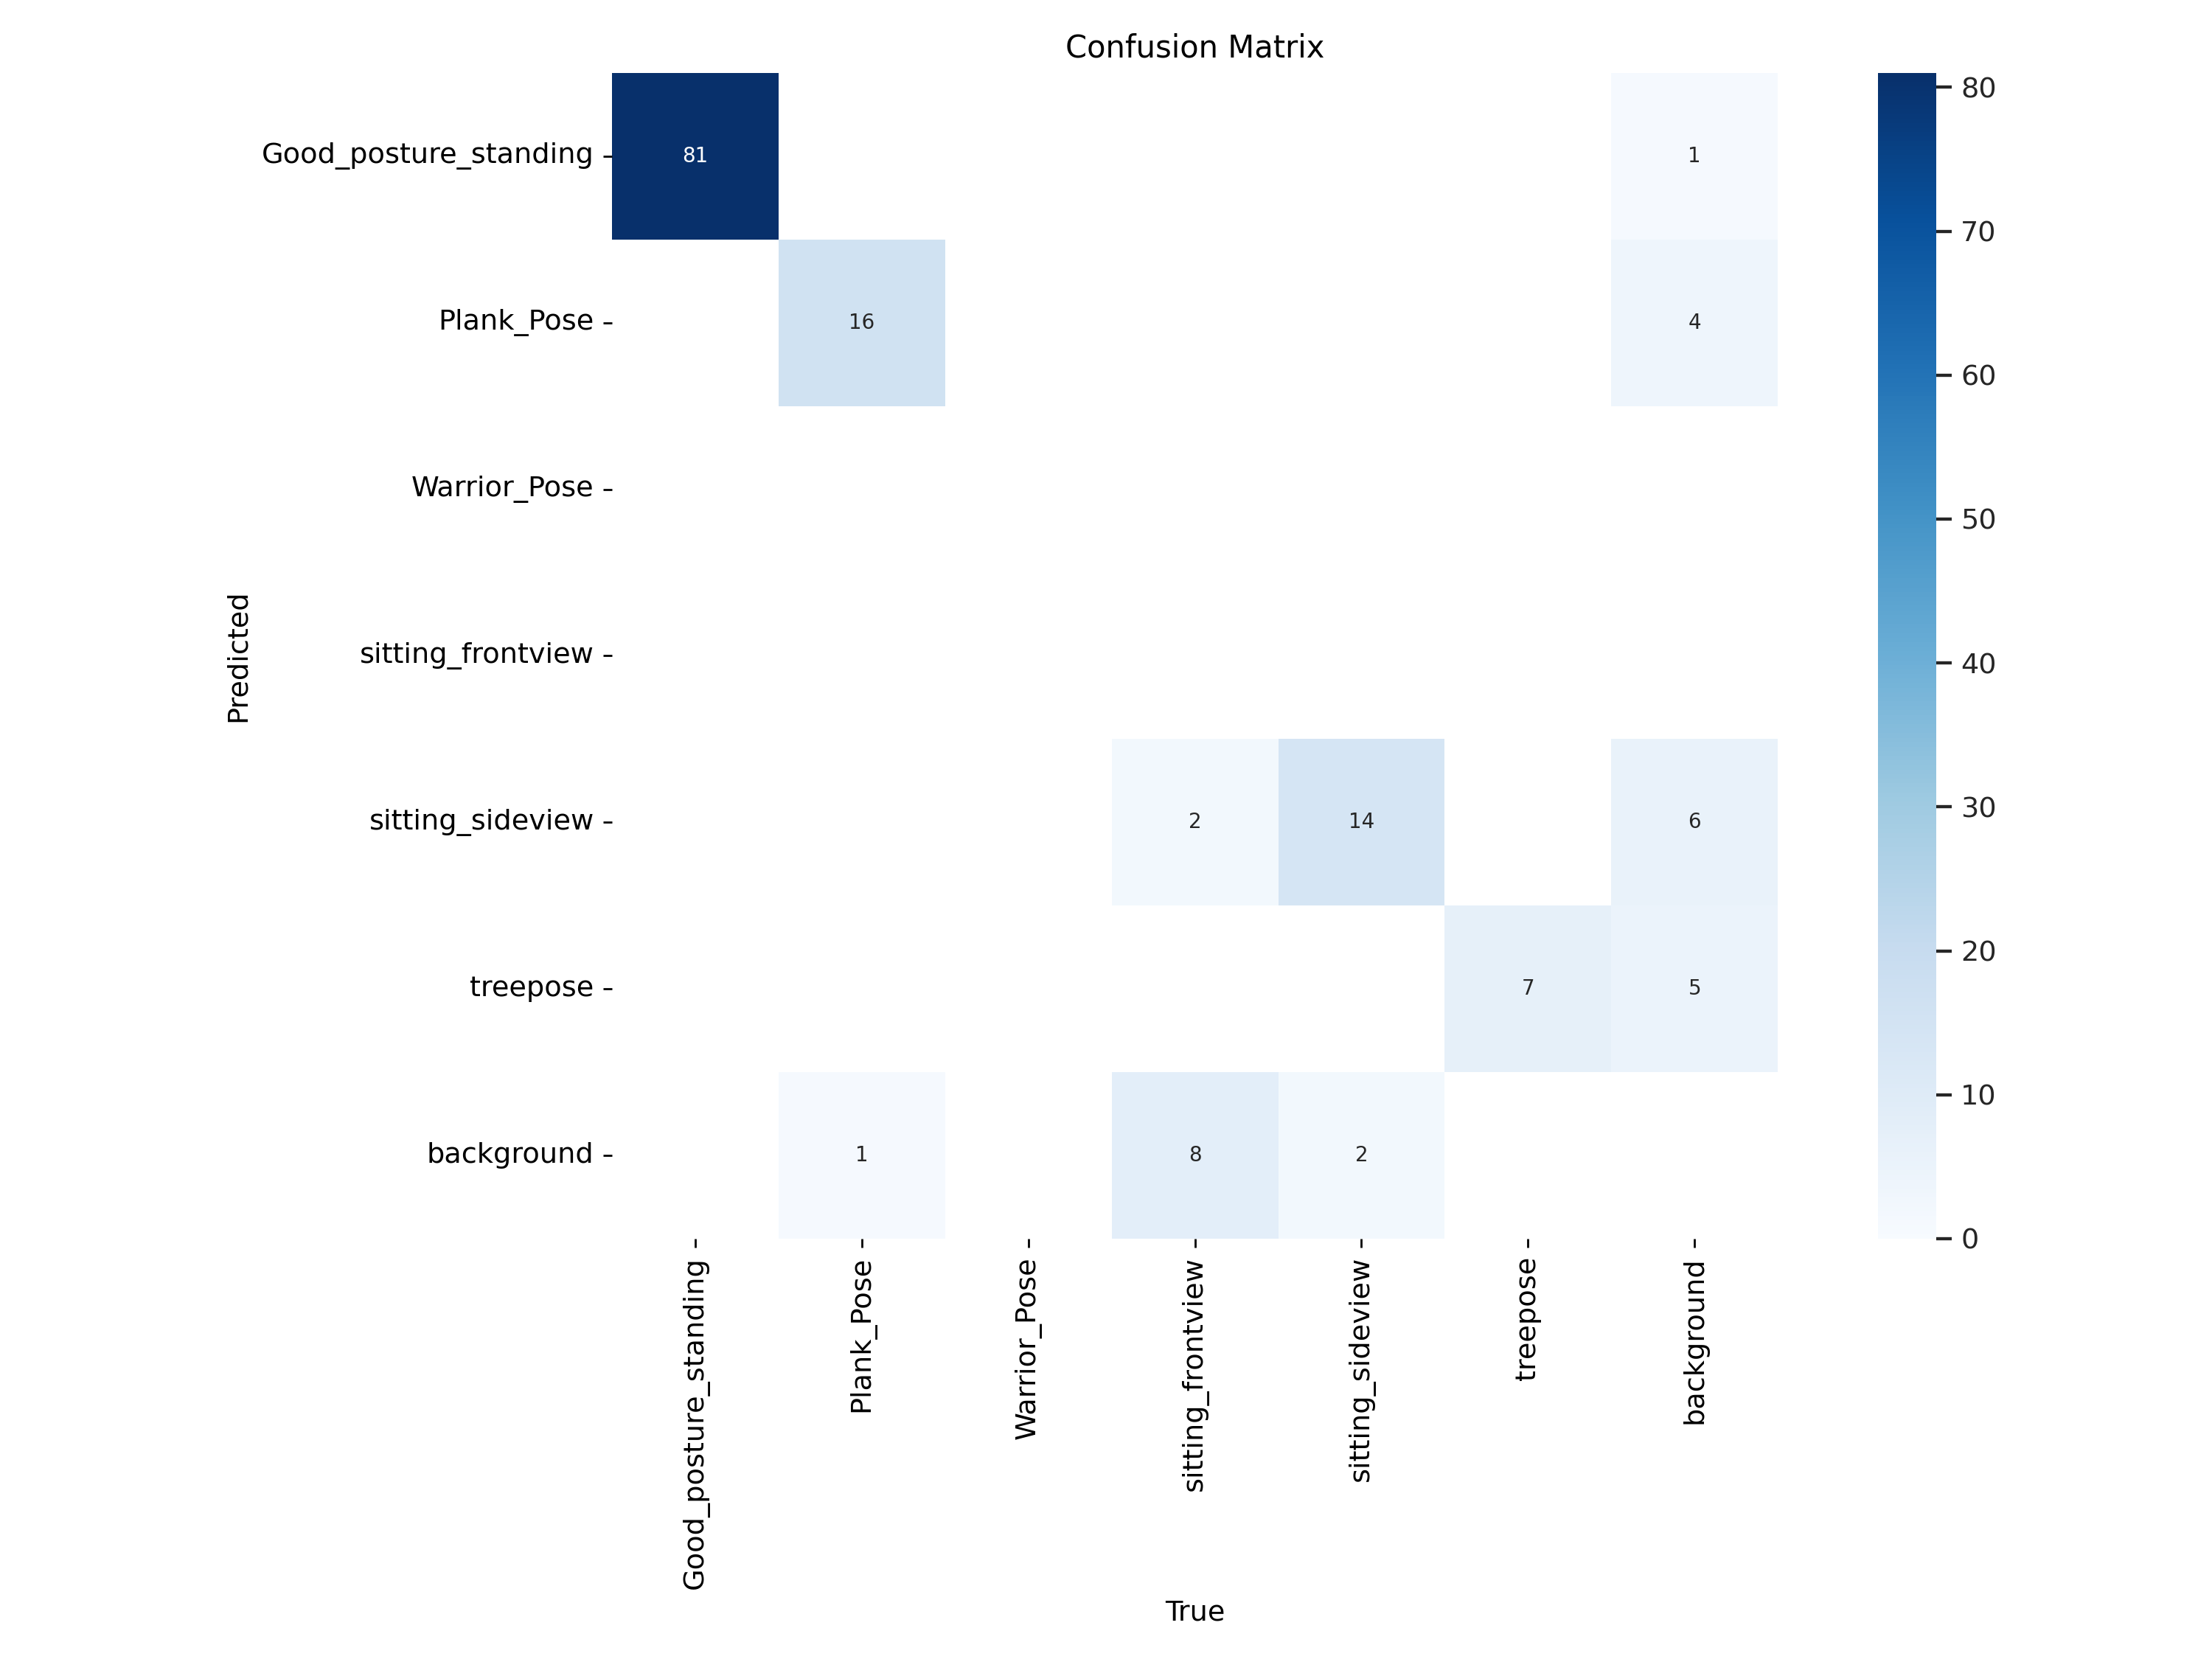

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train2/confusion_matrix.png', width=600)

In [ ]:
!yolo task=detect mode=predict model="/content/runs/detect/train2/weights/best.pt" source="/content/depositphotos_170928474-stock-photo-woman-standing-in-yoga-pose (1).jpg"

Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8n summary (fused): 168 layers, 3006818 parameters, 0 gradients, 8.1 GFLOPs

WARNING ⚠️ NMS time limit 0.550s exceeded
image 1/1 /content/depositphotos_170928474-stock-photo-woman-standing-in-yoga-pose (1).jpg: 416x416 2 treeposes, 18.5ms
Speed: 2.2ms preprocess, 18.5ms inference, 985.2ms postprocess per image at shape (1, 3, 416, 416)
Results saved to runs/detect/predict4
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [ ]:
# Load your trained YOLOv8 model
model = YOLO('/content/runs/detect/train2/weights/best.pt')

# Evaluate the model on a validation dataset
results = model.val(data='/content/datasets/humannn-pose-estimationn-2/data.yaml', imgsz=400, conf=0.25)

WARNING ⚠️ imgsz=[400] must be multiple of max stride 32, updating to [416]
Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8n summary (fused): 168 layers, 3006818 parameters, 0 gradients, 8.1 GFLOPs
val: Scanning /content/datasets/humannn-pose-estimationn-2/valid/labels.cache... 125 images, 0 backgrounds, 0 corrupt: 100%|██████████| 125/125 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.14it/s]
                   all        125        131      0.672      0.713      0.737      0.422
 Good_posture_standing        125         81      0.989          1      0.995      0.659
            Plank_Pose        125         17      0.886      0.882      0.956      0.705
     sitting_frontview        125         10          0          0          0          0
      sitting_sideview        125         16      0.845      0.681      0.814       0.25
             